In [1]:
import os, time
# 回到上一層資料夾
os.chdir('..')
# 打印當前工作目錄
print(os.getcwd())

d:\pythonProject\IC Lab\Gait_analysis\pyskl


In [2]:
print(os.getcwd())

d:\pythonProject\IC Lab\Gait_analysis\pyskl


In [3]:
import re
import numpy as np

def prinfo(b):

    # 打印輸出內容以便調試
    # print("\n".join(b))
    
    # 使用正則表達式提取 test_acc_list 和 val_acc_list
    test_acc_list_match = re.search(r"Test_acc_list:\s*\[([\d.,\s]+)\]", "\n".join(b))
    val_acc_list_match = re.search(r"Val_acc_list:\s*\[([\d.,\s]+)\]", "\n".join(b))
    train_time_list_match = re.search(r"Train_time_list:\s*\[([\d.,\s]+)\]", "\n".join(b))
    checkpoint_match = re.search(r"CheckPoint file\s*:\s*(\S+)", "\n".join(b))

    if test_acc_list_match and val_acc_list_match and train_time_list_match:
        # 將匹配到的字符串轉換為浮點數列表
        test_acc_list = list(map(float, test_acc_list_match.group(1).split(',')))
        val_acc_list = list(map(float, val_acc_list_match.group(1).split(',')))
        train_time_list = list(map(float, train_time_list_match.group(1).split(',')))
        checkpoint_file = checkpoint_match.group(1)
    else:
        raise ValueError("Could not extract test_acc_list or val_acc_list or train_time_list from script output")
    
    print("Extracted Test_acc_list:", test_acc_list)
    print("Extracted Val_acc_list:", val_acc_list)
    print("Extracted Train_time_list:", train_time_list)
    print("Extracted CheckPoint file:", checkpoint_file)

    # 返回提取的數據
    return np.mean(val_acc_list), np.mean(test_acc_list), np.mean(train_time_list), checkpoint_file

In [4]:
# 設定初始解
params = {
    'data'          : 'npz',            # 我自己讀特定資料集的方式
    'split'         : 1,                # 我自己讀特定資料集的方式
    'batch'         : 128,              # 可以調整~~
    'epoch'         : 80,               # 可以調整~~
    'frame'         : 90,               # 我自己讀特定資料集的方式
    'feature'       : 'j',              # 我自己讀特定資料集的方式
    'view'          : 'sagittal',       # 我自己讀特定資料集的方式
    'pose'          : 'yolo',           # 我自己讀特定資料集的方式
    'cls'           : 3,                # 我自己讀特定資料集的方式

    'base_channel'  : 64,               # output_channel in init_layer
    'num_init'      : 4,                # num_layers_input_stream

    'num_in'        : 3,                # num_layers_input_stream
    'tkernel_in'    : 3,                # tkernel_input_stream
    'stride_in'     : 2,                # stride_input_stream
    'oc_in'         : 128,              # output_channel_input_stream

    'num_main'      : 3,                # num_layers_main_stream
    'tkernel_main'  : 3,                # tkernel_main_stream
    'stride_main'   : 2,                # stride_main_stream
    'oc_main'       : 256,              # output_channel_main_stream

    'act'           : 0,                # activate function
    'opt'           : 0,                # optimizer
    
    'scheduler'     : 0,                # scheduler
    'dropout_bk'    : 0,                # dropout in block
    'dropout_fc'    : 0,                # dropout in fc

    'lr'            : 0.1,              # learning rate
    'weight_decay'  : 0.0005,           # weight_decay
    'momentum'      : 0.9,              # momentum
    'margin'        : 0.6,              # margin in Triplet Loss
    'lambda_val'    : 1,                # The ratio of Triplet Loss compare to Cross Entropy
}


# 設定要搜索的變數 & 範圍
params_range = {
    'base_channel'  : (64, 256),
    'num_init'      : (1, 3),           # num_layers_init_stream

    'num_in'        : (1, 3),           # num_layers_input_stream
    'tkernel_in'    : [3, 5, 7],        # tkernel_input_stream
    'stride_in'     : (1, 3),           # stride_input_stream
    'oc_in'         : (64, 256),        # output_channel_input_stream

    'num_main'      : (1, 3),           # num_layers_main_stream  (把它改成1,3)
    'tkernel_main'  : [3, 5, 7],        # tkernel_main_stream
    'stride_main'   : (1, 3),           # stride_main_stream
    'oc_main'       : (64, 256),        # output_channel_main_stream

    'act'           : [0, 1, 2, 3],     # activate function  
    'opt'           : [0, 1, 2],        # optimizer
    
    'scheduler'     : [0, 1],           # scheduler 0:True / 1:False
    'dropout_bk'    : (0.15, 0.3),      # dropout in block
    'dropout_fc'    : (0.15, 0.3),      # dropout in fc

    'lr'            : (0.001, 0.1),     # learning rate
    'weight_decay'  : (0, 0.01),        # weight_decay
    'momentum'      : (0.5, 0.99),      # momentum
    'margin'        : (0.25, 1),        # margin in Triplet Loss
    'lambda_val'    : (0, 1.5),         # The ratio of Triplet Loss compare to Cross Entropy
}

# 不用動
def get_param(X, keys=params_range.keys(), params=params):
    """
    Update `param` dictionary based on `keys` and corresponding values from `X`.

    Parameters:
        X (numpy.ndarray): Array of parameter values corresponding to the keys.
        keys (list): List of parameter names (keys) used to map values in X.
        params_range (dict): Search range for each parameter, where values can be
                             tuples (for range) or lists (for discrete options).

    Returns:
        dict: Updated `param` dictionary with values from `X`, converting to int if needed.
    """
    # 創建 `param` 的拷貝，避免修改原始字典
    param = params.copy()

    # 根據 keys 中的索引更新 param 中對應的鍵
    for i, key in enumerate(keys):
        # 判斷該參數是否需要轉換為整數
        boundary = params_range[key]
        if (
            isinstance(boundary, tuple) and all(isinstance(b, int) for b in boundary)
        ) or (
            isinstance(boundary, list) and all(isinstance(b, int) for b in boundary)
        ):
            # 如果是整數範圍或整數列表，將值轉換為整數
            param[key] = int(X[i])
        else:
            # 否則保留原類型
            param[key] = X[i]

    return param

# 適應度函數(自訂義)
def fitness(X):
    """
    Fitness function

    Parameters:
        X (numpy.ndarray): Array of parameter values for the model.
                           The array is expected to be a 1D array where each element corresponds 
                           to a specific parameter defined in `params_range.keys()`.

                           Example:
                           X = [base_channel, num_in, tkernel_in, stride_in, ...]

    Returns:
        fitness_value (float): Calculated fitness value based on the parameter values in X.
        record_message (dict): Dictionary containing the following metrics:
                               - 'val_acc' (float): Validation accuracy (fitness value).
                               - 'test_acc' (float): Test accuracy.
                               - 'train_time' (float): Time taken to compute the fitness value.
    """
    # 這個可以不用動，改下面就好了。
    param = get_param(X=X)
    
    
    # ---------------從這邊開始改---------------
    # 将 params 中的键值对动态构造成命令行参数
    param_args = " ".join([f"--{key} {value}" for key, value in param.items()])
    
    # 建構cmd命令
    command = f"python -m colab.training_tools.kaggle_train_stgcnpp_SSO {param_args}"
    print(command)
    # 直接運行,b用來接log的輸出
    b = !{command}
    print(b)

    # 解析b (log)
    fitness_value, test_acc, train_time, checkpoint_file = prinfo(b)
    
    # Record message 建議使用字典，以便索引
    record_message = {
                    'val_acc': fitness_value,
                    'test_acc': test_acc,
                    'train_time':train_time,
                    'weights' : checkpoint_file, #模型權重路徑         
                }
    
    return fitness_value, record_message

python -m colab.training_tools.kaggle_train_stgcnpp_SSO --data npz --split 1 --batch 4 --epoch 3 --frame 90 --feature j --view sagittal --pose yolo --cls 3 --base_channel 64 --num_in 3 --tkernel_in 3 --stride_in 2 --oc_in 128 --num_main 3 --tkernel_main 3 --stride_main 2 --oc_main 256 --act 0 --opt 0 --scheduler 0 --dropout_bk 0.0 --dropout_fc 0.0 --lr 0.1 --weight_decay 0.0005 --momentum 0.9 --margin 0.6 --lambda_val 1.0
['Epoch:0001 train lr:0.075000 loss:1.973944 acc:53.808594 | val loss:0.843887 acc:61.718750', 'Epoch:0002 train lr:0.025000 loss:1.224746 acc:65.527344 | val loss:0.733186 acc:66.796875', 'Epoch:0003 train lr:0.000000 loss:1.130493 acc:68.261719 | val loss:0.681850 acc:66.406250', '0 : 80.0000', 'Train cost: 80.9072s', 'Test_acc_list: [80.0]', 'Val_acc_list: [66.40625]', 'Train_time_list: [71.14778232574463]', 'Test_time_list: [8.699427127838135]', 'Final Test Accuracy: 80.0', 'Final Val Accuracy: 66.40625']
Extracted Test_acc_list: [80.0]
Extracted Val_acc_list: [66

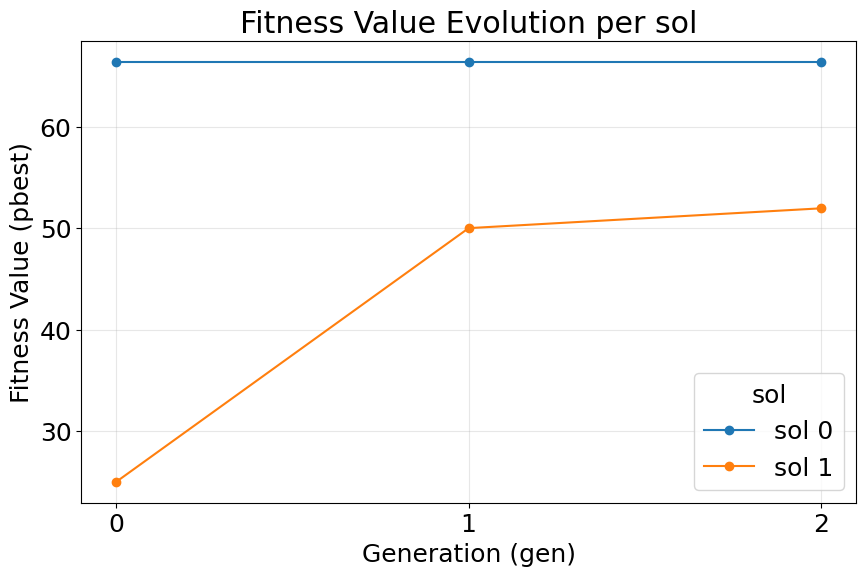

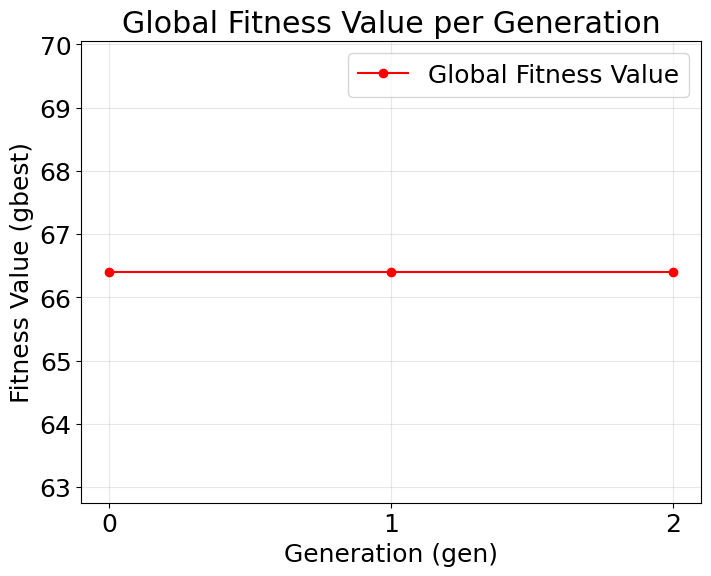

In [5]:
from colab.SSO import SSO

SSO_searcher = SSO(
    Ngen=2,                                 # 世代數
    Nsol=2,                                 # 解的數量
    Cg=0.4,                                 # 全局最佳解的權重
    Cp=0.7,                                 # 個體最佳解的權重
    Cw=0.9,                                 # 隨機解的權重
    save_name='test',                       # 記錄檔儲存前綴
    fitness=fitness,                        # 適應度函數
    base_param=params,                      # 基礎參數 (可選)
    boundary=params_range,                  # 支持 tuple 或 list (詳細說明請參照前述)
    direction="maximize",                   # 優化方向 ('maximize', 'minimize')
    )

# 直接運行
SSO_searcher.run()
SSO_searcher.plot()

# # 可以接這個操作固定清空pretrained資料夾---------------------------------------------------------
# file_name = SSO_searcher.ckpt[SSO_searcher.genBest][SSO_searcher.gBest]['message']['weights']
# folder_path = os.path.dirname(file_name)

# # 刪除資料夾中其他檔案，僅保留目標檔案
# for file in os.listdir(folder_path):
#     full_path = os.path.join(folder_path, file)
#     if full_path != file_name and os.path.isfile(full_path):
#         os.remove(full_path)  # 刪除非目標檔案
# print(f"Retained: {file_name}")

# 直接看這邊

In [6]:
import re
import numpy as np

def prinfo(b):

    # 打印輸出內容以便調試
    # print("\n".join(b))
    
    # 使用正則表達式提取 test_acc_list 和 val_acc_list
    test_acc_list_match = re.search(r"Test_acc_list:\s*\[([\d.,\s]+)\]", "\n".join(b))
    val_acc_list_match = re.search(r"Val_acc_list:\s*\[([\d.,\s]+)\]", "\n".join(b))
    train_time_list_match = re.search(r"Train_time_list:\s*\[([\d.,\s]+)\]", "\n".join(b))

    if test_acc_list_match and val_acc_list_match and train_time_list_match:
        # 將匹配到的字符串轉換為浮點數列表
        test_acc_list = list(map(float, test_acc_list_match.group(1).split(',')))
        val_acc_list = list(map(float, val_acc_list_match.group(1).split(',')))
        train_time_list = list(map(float, train_time_list_match.group(1).split(',')))
    else:
        raise ValueError("Could not extract test_acc_list or val_acc_list or train_time_list from script output")
    
    print("Extracted Test_acc_list:", test_acc_list)
    print("Extracted Val_acc_list:", val_acc_list)
    print("Extracted Train_time_list:", train_time_list)

    return np.mean(val_acc_list), np.mean(test_acc_list), np.mean(train_time_list)

params = params = {
    'data'          : 'npz',
    'split'         : 1,
    'batch'         : 4,
    'epoch'         : 3,
    'frame'         : 90,
    'feature'       : 'j',
    'view'          : 'sagittal',
    'pose'          : 'yolo',
    'cls'           : 3,

    'base_channel'  : 64,               # output_channel in init_layer

    'num_in'        : 3,                # num_layers_input_stream
    'tkernel_in'    : 3,                # tkernel_input_stream
    'stride_in'     : 2,                # stride_input_stream
    'oc_in'         : 128,              # output_channel_input_stream

    'num_main'      : 3,                # num_layers_main_stream
    'tkernel_main'  : 3,                # tkernel_main_stream
    'stride_main'   : 2,                # stride_main_stream
    'oc_main'       : 256,              # output_channel_main_stream

    'act'           : 0,                # activate function
    'opt'           : 0,                # optimizer
    
    'scheduler'     : 0,                # scheduler
    'dropout_bk'    : 0,                # dropout in block
    'dropout_fc'    : 0,                # dropout in fc

    'lr'            : 0.1,              # learning rate
    'weight_decay'  : 0.0005,           # weight_decay
    'momentum'      : 0.9,              # momentum
    'margin'        : 0.6,              # margin in Triplet Loss
    'lambda_val'    : 1,                # The ratio of Triplet Loss compare to Cross Entropy
}

param_args = " ".join([f"--{key} {value}" for key, value in params.items()])
command = f"python -m colab.training_tools.kaggle_train_stgcnpp_SSO {param_args}"
print(f"COMMAND : ")
print(command)

b = !{command} 

print(b)
v, t, time_spend = prinfo(b)

print(f"val_acc     : {v}")
print(f"test_acc    : {t}")
print(f"train_time  : {time_spend}s")

COMMAND : 
python -m colab.training_tools.kaggle_train_stgcnpp_SSO --data npz --split 1 --batch 4 --epoch 3 --frame 90 --feature j --view sagittal --pose yolo --cls 3 --base_channel 64 --num_in 3 --tkernel_in 3 --stride_in 2 --oc_in 128 --num_main 3 --tkernel_main 3 --stride_main 2 --oc_main 256 --act 0 --opt 0 --scheduler 0 --dropout_bk 0 --dropout_fc 0 --lr 0.1 --weight_decay 0.0005 --momentum 0.9 --margin 0.6 --lambda_val 1
['Epoch:0001 train lr:0.075000 loss:2.537286 acc:39.941406 | val loss:1.044074 acc:50.000000', 'Epoch:0002 train lr:0.025000 loss:1.717931 acc:47.558594 | val loss:1.039036 acc:50.000000', 'Epoch:0003 train lr:0.000000 loss:1.565140 acc:50.976562 | val loss:1.026533 acc:49.218750', '0 : 52.1875', 'Train cost: 78.8573s', 'Test_acc_list: [52.1875]', 'Val_acc_list: [49.21875]', 'Train_time_list: [69.29093527793884]', 'Test_time_list: [8.575359106063843]', 'Final Test Accuracy: 52.1875', 'Final Val Accuracy: 49.21875']
Extracted Test_acc_list: [52.1875]
Extracted Val

In [ ]:
from colab.SSO import SSO

SSO_searcher = SSO(
    Ngen=2,                                 # 世代數
    Nsol=2,                                 # 解的數量
    Cg=0.4,                                 # 全局最佳解的權重
    Cp=0.7,                                 # 個體最佳解的權重
    Cw=0.9,                                 # 隨機解的權重
    save_name='test',                       # 記錄檔儲存前綴
    fitness=fitness,                        # 適應度函數
    base_param=params,                      # 基礎參數 (可選)
    boundary=params_range,                  # 支持 tuple 或 list (詳細說明請參照前述)
    direction="maximize",                   # 優化方向 ('maximize', 'minimize')
    )

# 直接運行
SSO_searcher.run()
SSO_searcher.plot()


# SSO_searcher.sensitivity_analysis(files=[], y_value='val_acc')

python -m colab.training_tools.kaggle_train_stgcnpp_SSO --data npz --split 1 --batch 4 --epoch 3 --frame 90 --feature j --view sagittal --pose yolo --cls 3 --base_channel 64 --num_in 3 --tkernel_in 3 --stride_in 2 --oc_in 128 --num_main 3 --tkernel_main 3 --stride_main 2 --oc_main 256 --act 0 --opt 0 --scheduler 0 --dropout_bk 0.0 --dropout_fc 0.0 --lr 0.1 --weight_decay 0.0005 --momentum 0.9 --margin 0.6 --lambda_val 1.0


In [1]:
import os, time
# 回到上一層資料夾
os.chdir('..')
# 打印當前工作目錄
print(os.getcwd())

d:\pythonProject\IC Lab\Gait_analysis\pyskl


In [2]:
from colab.utils.datasets_npz import load_npz_dataset
pose = 'yolo'
view = 'sagittal'
frame = 90
cls = 3
batch = 3
feature = 'bm'

train_file = 'colab/data/' + 'dataset_' + pose + '_' + view + '_split1_'+ str(frame) + 'frames_j_' + str(cls) + 'class_train.npz'
validation_file = 'colab/data/' + 'dataset_' + pose + '_' + view + '_split1_'+ str(frame) + 'frames_j_' + str(cls) + 'class_val.npz'
test_file = 'colab/data/' + 'dataset_' + pose + '_' + view + '_split1_'+ str(frame) + 'frames_j_' + str(cls) + 'class_test.npz'

training_loader = load_npz_dataset(train_file, workers_per_gpu=2, batch_size=batch, pose=pose, feature=feature)
validation_loader = load_npz_dataset(validation_file, workers_per_gpu=2, batch_size=batch, pose=pose, feature=feature)
test_loader = load_npz_dataset(test_file, workers_per_gpu=2, batch_size=batch, pose=pose, feature=feature)


transform to b
transform to m
Input keypoints shape: (1024, 1, 90, 17, 3)
Diff shape: (1024, 1, 89, 17, 3)
Motion shape: (1024, 1, 90, 17, 3)
(1024, 1, 90, 17, 3)
transform to b
transform to m
Input keypoints shape: (256, 1, 90, 17, 3)
Diff shape: (256, 1, 89, 17, 3)
Motion shape: (256, 1, 90, 17, 3)
(256, 1, 90, 17, 3)
transform to b
transform to m
Input keypoints shape: (320, 1, 90, 17, 3)
Diff shape: (320, 1, 89, 17, 3)
Motion shape: (320, 1, 90, 17, 3)
(320, 1, 90, 17, 3)
